# data load 


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

# Load data
df = pd.read_csv(r'C:\Users\ThinkPad\Downloads\Attack_Dataset.csv')
df.columns = df.columns.str.strip()

# Bikin 3 kolom numerik
df['desc_len'] = df['Scenario Description'].str.len()
df['steps_len'] = df['Attack Steps'].str.len()
df['tools_count'] = df['Tools Used'].str.count(',') + 1

print("Shape:", df.shape)
df[['desc_len', 'steps_len', 'tools_count']].head()

# Statistik Deskriptif Numerik

In [27]:
num_cols = ['desc_len', 'steps_len', 'tools_count']

summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Modus': df[num_cols].mode().iloc[0],
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Range': df[num_cols].max() - df[num_cols].min(),
    'Varians': df[num_cols].var(),
    'Std': df[num_cols].std(),
    'Q1': df[num_cols].quantile(0.25),
    'Q3': df[num_cols].quantile(0.75),
    'IQR': df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
}).round(2)

summary

,Mean,Median,Modus,Min,Max,Range,Varians,Std,Q1,Q3,IQR
desc_len,127.57,103.0,84.0,30.0,795.0,765.0,8268.96,90.93,79.0,143.0,64.0
steps_len,698.13,554.0,399.0,23.0,6003.0,5980.0,215959.70,464.71,387.0,890.0,503.0
tools_count,2.94,3.0,3.0,1.0,22.0,21.0,1.57,1.25,2.0,3.0,1.0


### Interpretasi

**`desc_len` (panjang deskripsi):**  
Rata-rata panjang deskripsi adalah **127,57 karakter**, sedangkan nilai tengahnya (median) **103 karakter**. Karena rata-rata lebih besar dari median, berarti ada beberapa deskripsi yang jauh lebih panjang sehingga menarik rata-ratanya ke atas. Sebagian besar deskripsi berada di sekitar **79–143 karakter** (Q1–Q3).

**`steps_len` (panjang langkah serangan):**  
Rata-ratanya **698,13 karakter**, sedangkan mediannya hanya **554 karakter**. Perbedaan ini cukup besar, menunjukkan ada beberapa langkah serangan yang sangat panjang dibandingkan yang lainnya. Jadi, data `steps_len` memiliki **variasi yang cukup besar** (simpangan baku 464,71).

**`tools_count` (jumlah tools yang digunakan):**  
Rata-ratanya sekitar **2,94 tools**, dengan median dan modus sama-sama **3 tools**. Artinya, sebagian besar serangan menggunakan sekitar 3 tools. Nilainya juga tidak terlalu menyebar (IQR = 1), sehingga jumlah tools yang digunakan cenderung **lebih stabil** dibandingkan dua variabel lainnya.

### Kesimpulan

Dari ketiga variabel numerik tersebut, **`steps_len` paling tidak konsisten** karena panjangnya sangat bervariasi. **`desc_len`** juga memiliki beberapa nilai yang cukup jauh dari kebanyakan data, tetapi variasinya tidak sebesar `steps_len`. Sementara itu, **`tools_count` paling stabil** karena sebagian besar datanya berada di sekitar 3 tools.

# Nilai Plus : Hitung varians manual

In [29]:
x = df['desc_len'].head(10)
n = len(x)
xbar = x.mean()

manual_var = ((x - xbar) ** 2).sum() / (n - 1)
manual_std = manual_var ** 0.5

print(f"Manual varians : {manual_var:.2f}")
print(f"Pandas varians : {x.var():.2f}")
print(f"Selisih        : {abs(manual_var - x.var()):.6f}")

Manual varians : 4640.22
Pandas varians : 4640.22
Selisih        : 0.000000


**Interpretasi:** Hasil perhitungan varians manual dengan rumus s² = Σ(xᵢ − x̄)² / (n − 1) menggunakan 10 baris pertama menghasilkan nilai yang sama (selisih ≈ 0) dengan hasil pandas `var()`. Ini membuktikan bahwa pandas menggunakan pembagi **n − 1** (sampel), bukan n (populasi).


# Ringkasan Variabel Kategorik

In [31]:
# Hitung frekuensi & persentase
freq = df['Category'].value_counts()
pct = (df['Category'].value_counts(normalize=True) * 100).round(2)

# Gabung jadi tabel
tabel = pd.DataFrame({
    'Frekuensi': freq,
    'Persentase (%)': pct
})

print(f"Jumlah kategori unik: {df['Category'].nunique()}")
print(f"\nModus (paling sering): {df['Category'].mode()[0]} — {freq.max()} serangan")

print("\n=== 10 Kategori Terbanyak ===")
print(tabel.head(10))

print("\n=== 10 Kategori Paling Sedikit ===")
print(tabel.tail(10))

Jumlah kategori unik: 64

Modus (paling sering): Insider Threat — 569 serangan

=== 10 Kategori Terbanyak ===
                                             Frekuensi  Persentase (%)
Category                                                              
Insider Threat                                     569            4.03
Physical / Hardware Attacks                        548            3.88
Quantum Cryptography & Post-Quantum Threats        542            3.83
Wireless Attacks (Advanced)                        535            3.79
Malware & Threat                                   528            3.74
Satellite & Space Infrastructure Security          515            3.64
DFIR                                               510            3.61
Blockchain / Web3                                  503            3.56
Red Team                                           503            3.56
Blue Team                                          503            3.56

=== 10 Kategori Paling Sedikit ===
  



Pada kolom `Category`, terdapat **64 jenis kategori** serangan. Kategori yang paling sering muncul (modus) adalah **Insider Threat**, yaitu sebanyak **569 serangan** atau **4,03%** dari seluruh data.

Lima kategori yang paling sering muncul adalah:
1. Insider Threat (569)
2. Physical / Hardware Attacks (548)
3. Quantum Cryptography & Post-Quantum Threats (542)
4. Wireless Attacks Advanced (535)
5. Malware & Threat (528)

Jumlah masing-masing kategori tersebut **tidak jauh berbeda**, yaitu berkisar **3,7%–4%**.

### Kesimpulan

Artinya, tidak ada satu jenis serangan yang **sangat mendominasi** data. Jenis serangannya cukup beragam dan jumlahnya tersebar di banyak kategori. Selain itu, ada juga beberapa kategori yang hanya muncul sedikit, bahkan **kurang dari 10 kali**, seperti Automotive / CPS → Sensor Spoofing (7), Network security (2), dan Mobile Security (1). Data menunjukkan bahwa serangan yang terjadi memiliki **banyak jenis dengan jumlah yang cukup merata** pada kategori-kategori teratas.

# Histogram desc_len

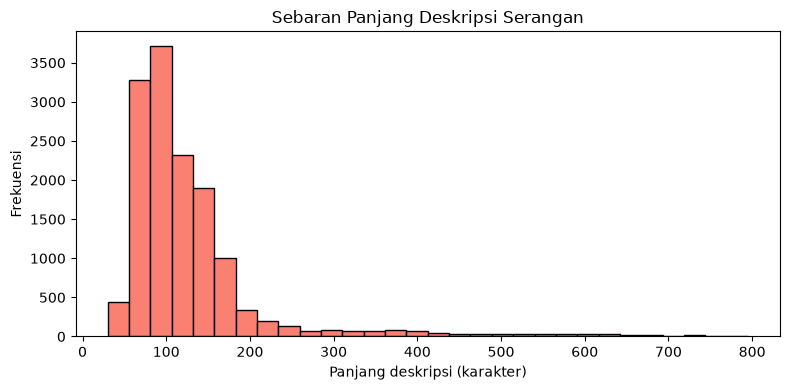

In [32]:
plt.figure(figsize=(8, 4))
plt.hist(df['desc_len'], bins=30, color='salmon', edgecolor='black')
plt.title('Sebaran Panjang Deskripsi Serangan')
plt.xlabel('Panjang deskripsi (karakter)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Histogram `desc_len` menunjukkan sebaran yang **miring ke kanan** (*right-skewed*). Mayoritas deskripsi serangan panjangnya berada di kisaran **50–150 karakter**, dengan puncak frekuensi tertinggi di sekitar **80–100 karakter**.

Namun, ada **ekor panjang ke kanan** yang mencapai **795 karakter**. Ini menandakan bahwa sebagian kecil serangan memiliki deskripsi yang jauh lebih detail dan panjang dibandingkan mayoritas.

**Kesimpulan:** Sebagian besar deskripsi serangan cenderung singkat, tetapi ada beberapa serangan yang deskripsinya sangat panjang. Hal ini sejalan dengan nilai mean (127,57) yang lebih besar dari median (103), yang mengonfirmasi bentuk sebaran miring ke kanan.

# Histogram steps_len

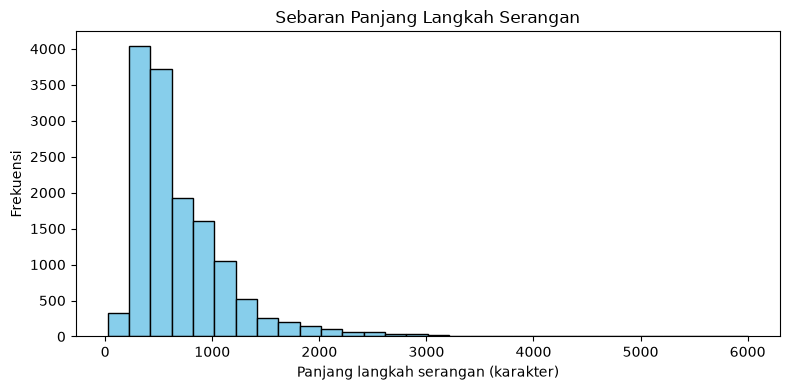

In [36]:
plt.figure(figsize=(8, 4))
plt.hist(df['steps_len'], bins=30, color='skyblue', edgecolor='black')
plt.title('Sebaran Panjang Langkah Serangan')
plt.xlabel('Panjang langkah serangan (karakter)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Histogram `steps_len` menunjukkan sebaran panjang langkah-langkah serangan. Sebagian besar langkah serangan memiliki panjang sekitar **200–800 karakter**.

Namun, ada beberapa serangan yang langkahnya jauh lebih panjang, bahkan mencapai **6.003 karakter**. Hal ini membuat grafik terlihat **memanjang ke arah kanan** (*right-skewed*).

**Kesimpulan:** Kebanyakan serangan memiliki langkah yang cukup singkat, tetapi ada beberapa serangan yang membutuhkan penjelasan atau langkah-langkah yang jauh lebih detail. Hal ini sejalan dengan nilai mean (698,13) yang jauh lebih besar dari median (554), yang mengonfirmasi bentuk sebaran sangat miring ke kanan.

# Boxplot 3 Kolom

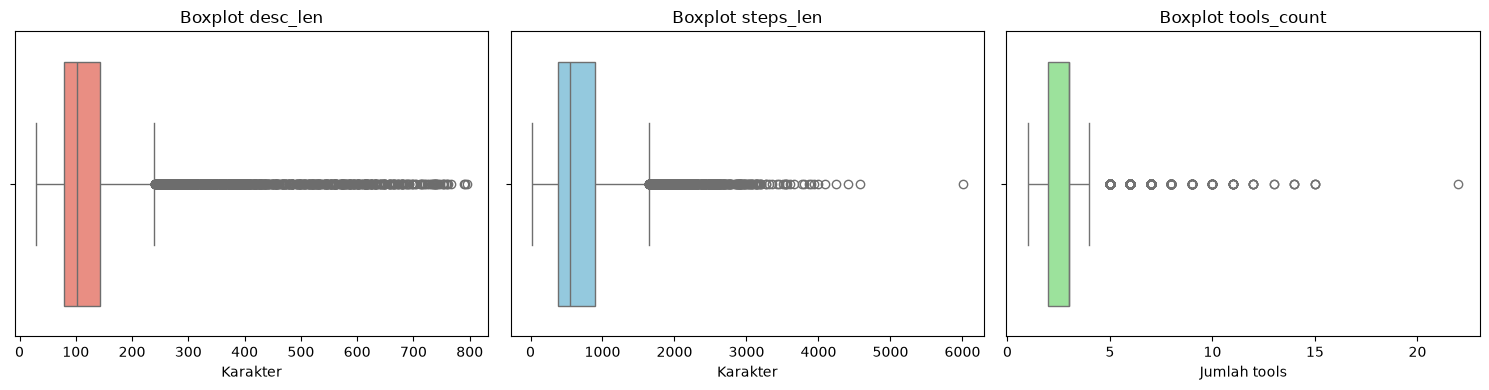

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x=df['desc_len'], ax=axes[0], color='salmon')
axes[0].set_title('Boxplot desc_len')
axes[0].set_xlabel('Karakter')

sns.boxplot(x=df['steps_len'], ax=axes[1], color='skyblue')
axes[1].set_title('Boxplot steps_len')
axes[1].set_xlabel('Karakter')

sns.boxplot(x=df['tools_count'], ax=axes[2], color='lightgreen')
axes[2].set_title('Boxplot tools_count')
axes[2].set_xlabel('Jumlah tools')

plt.tight_layout()
plt.show()

Ketiga boxplot menunjukkan adanya beberapa nilai yang jauh lebih tinggi dibandingkan data lainnya. Nilai seperti ini disebut **pencilan (outlier)**.

Pada `steps_len`, terdapat beberapa data dengan panjang langkah yang sangat besar, bahkan lebih dari **3.000 karakter**. Sementara itu, `tools_count` juga memiliki beberapa data yang menggunakan hingga **22 tools**. Sedangkan pada `desc_len`, outliernya tidak sejauh dua variabel lainnya.

**Kesimpulan:** Sebagian besar serangan memiliki ukuran dan jumlah tools yang normal, tetapi ada beberapa serangan yang jauh lebih panjang atau menggunakan lebih banyak tools. Hal ini menunjukkan bahwa serangan tertentu membutuhkan proses yang lebih rumit atau lebih detail dibandingkan serangan lainnya.

# Cek Outlier 1.5 x IQR

In [38]:
for k in ['desc_len', 'steps_len', 'tools_count']:
    Q1 = df[k].quantile(0.25)
    Q3 = df[k].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[k] < lower) | (df[k] > upper)]
    print(f"{k}: {len(outliers)} outlier (batas {lower:.1f} – {upper:.1f})")

desc_len: 891 outlier (batas -17.0 – 239.0)
steps_len: 652 outlier (batas -367.5 – 1644.5)
tools_count: 1136 outlier (batas 0.5 – 4.5)


### Interpretasi

Dengan menggunakan aturan **1,5 × IQR**, diperoleh jumlah pencilan (outlier) untuk masing-masing kolom numerik:

| Kolom | Jumlah Outlier | Batas Bawah | Batas Atas |
|---|---|---|---|
| `desc_len` | 891 | -17,0 | 239,0 |
| `steps_len` | 652 | -367,5 | 1.644,5 |
| `tools_count` | 1.136 | 0,5 | 4,5 |

- **`desc_len`** memiliki **891 outlier**, yaitu deskripsi yang panjangnya di atas **239 karakter**.
- **`steps_len`** memiliki **652 outlier**, yaitu langkah serangan yang panjangnya di atas **1.644,5 karakter**.
- **`tools_count`** memiliki **1.136 outlier**, yaitu serangan yang menggunakan lebih dari **4,5 tools** (artinya 5 tools ke atas).

**Kesimpulan:** Ketiga kolom memiliki pencilan di sisi kanan, yang berarti ada sebagian kecil serangan dengan tingkat kompleksitas yang jauh di atas mayoritas — baik dari sisi panjang deskripsi, panjang langkah, maupun jumlah tools yang digunakan. `tools_count` memiliki jumlah outlier terbanyak (1.136), sedangkan `steps_len` memiliki outlier dengan nilai paling ekstrem (hingga 6.003 karakter).

# Diagram Batang Kategorik

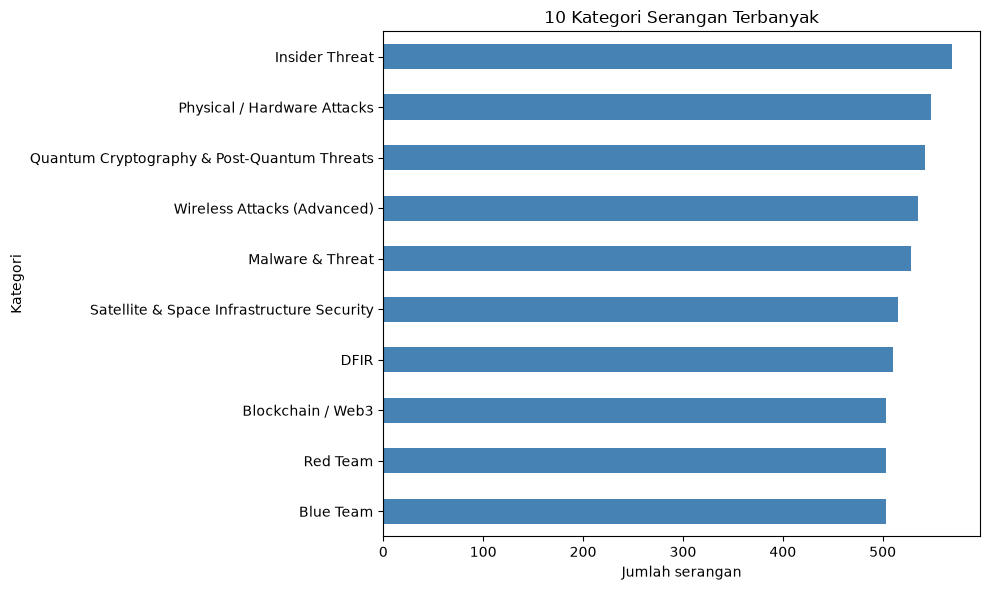

In [41]:
df['Category'].value_counts().head(10).plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.title('10 Kategori Serangan Terbanyak')
plt.xlabel('Jumlah serangan')
plt.ylabel('Kategori')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Diagram batang menunjukkan **10 kategori serangan yang paling sering muncul** dalam data.

Kategori **Insider Threat** memiliki jumlah paling banyak, yaitu **569 serangan**. Setelah itu ada **Physical/Hardware Attacks** sebanyak **548 serangan** dan **Quantum Cryptography** sebanyak **542 serangan**.

Jumlah 10 kategori teratas berada di sekitar **500–569 serangan**, sehingga perbedaannya tidak terlalu jauh.

**Kesimpulannya:** tidak ada satu kategori serangan yang jumlahnya jauh lebih banyak dari kategori lainnya. Data serangan **tersebar cukup merata di antara berbagai kategori**.


# Nilai Plus: Groupby Median per Kategori

Category
Blue Team                                       68.0
DFIR                                            75.0
Physical / Hardware Attacks                     77.0
Malware & Threat                                82.0
Red Team                                        82.0
Satellite & Space Infrastructure Security       84.0
Insider Threat                                  89.0
Wireless Attacks (Advanced)                     97.0
Quantum Cryptography & Post-Quantum Threats    119.0
Blockchain / Web3                              150.0
Name: desc_len, dtype: float64


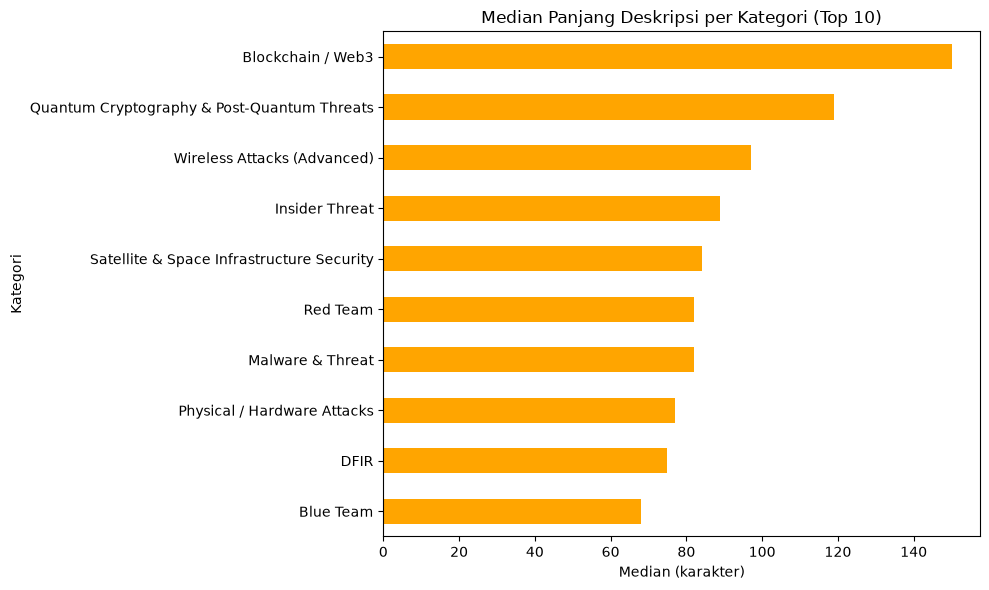

In [43]:
top_cat = df['Category'].value_counts().head(10).index
subset = df[df['Category'].isin(top_cat)]

median_per_cat = subset.groupby('Category')['desc_len'].median().sort_values()

print(median_per_cat)

median_per_cat.plot(kind='barh', color='orange', figsize=(10, 6))
plt.title('Median Panjang Deskripsi per Kategori (Top 10)')
plt.xlabel('Median (karakter)')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()



Median adalah **nilai tengah** dari data. Jadi, grafik ini menunjukkan **panjang deskripsi yang biasanya dimiliki oleh setiap kategori serangan**.

Nilai median panjang deskripsi berbeda-beda di setiap kategori. Kategori dengan median paling tinggi berarti **deskripsi serangannya biasanya lebih panjang dan lebih detail**. Sebaliknya, kategori dengan median paling rendah berarti **deskripsinya cenderung lebih singkat**.

**Kesimpulannya:** setiap kategori memiliki tingkat detail deskripsi yang berbeda-beda. Ada kategori yang biasanya dijelaskan dengan lebih panjang, dan ada juga yang cukup dijelaskan secara singkat.


# Kesimpulan

### Jawaban Pertanyaan

1. **Rata-rata panjang deskripsi serangan** adalah **127,57 karakter**. Nilai rata-ratanya lebih besar dari nilai tengahnya (median 103), sehingga sebagian data memiliki deskripsi yang jauh lebih panjang. Penyebaran datanya juga cukup beragam, dengan simpangan baku **90,93 karakter**.

2. **Rata-rata jumlah tools** yang digunakan dalam satu serangan adalah sekitar **2,94 tools**. Nilai ini hampir sama dengan mediannya, yaitu **3 tools**, sehingga jumlah tools yang digunakan cenderung **cukup stabil**, biasanya sekitar 2–3 tools.

3. **Rata-rata panjang langkah serangan** adalah **698,13 karakter**, sedangkan mediannya **554 karakter**. Perbedaan ini menunjukkan bahwa sebagian besar langkah serangan tidak terlalu panjang, tetapi ada beberapa serangan dengan langkah yang **sangat panjang**, bahkan mencapai **6.003 karakter**.

### 5 Temuan Menarik

1. **Insider Threat** merupakan kategori yang paling sering muncul, yaitu **569 serangan (4,03%)**.
2. `steps_len` memiliki variasi paling besar. Artinya, panjang langkah antarserangan bisa sangat berbeda.
3. `tools_count` merupakan data yang paling stabil. Mayoritas serangan menggunakan sekitar **2–3 tools**.
4. Terdapat banyak data yang berbeda cukup jauh dari mayoritas, yaitu **891 pada `desc_len`**, **652 pada `steps_len`**, dan **1.136 pada `tools_count`**.
5. Terdapat **64 kategori serangan**, tetapi jumlah datanya tidak sama. Hanya **10 kategori teratas** yang memiliki lebih dari 400 serangan, sedangkan kategori lainnya memiliki jumlah yang lebih sedikit.

### Keterbatasan Data

* Data ini lebih seperti **kumpulan informasi atau deskripsi tentang serangan**, bukan catatan serangan yang benar-benar terjadi di jaringan.
* Data bersifat **sintetis**, sehingga belum tentu menggambarkan kondisi serangan siber di dunia nyata.
* Beberapa informasi berupa teks yang panjang, sehingga lebih sulit untuk diubah menjadi angka dan dianalisis.
* Jumlah data pada setiap kategori berbeda-beda. Beberapa kategori memiliki banyak data, sementara kategori lainnya hanya memiliki sedikit data.

### Pertanyaan yang Bisa Diteliti Selanjutnya

Dari hasil analisis ini, kita masih bisa mencari tahu beberapa hal, misalnya:

* Apakah serangan yang menggunakan **lebih banyak tools** juga memiliki deskripsi yang lebih panjang?
* Kategori serangan mana yang memiliki **langkah-langkah paling panjang**?
* Apakah **panjang deskripsi** berhubungan dengan **panjang langkah serangan**?
* Apakah semakin banyak tools yang digunakan berarti langkah serangannya juga semakin panjang?

**Secara sederhana, dataset ini menunjukkan bahwa setiap serangan memiliki tingkat detail yang berbeda-beda. Kebanyakan serangan berada pada ukuran yang relatif normal, tetapi ada beberapa serangan yang jauh lebih panjang dan menggunakan lebih banyak tools.**
